# Half-hourly settlement data and panel (many-meter) operations

UK electricity settles in **half-hour periods**: 48 per day, 46 on the spring DST day and
50 on the autumn one. Meter data arrives as `settlement_date` (local) + `settlement_period`
per meter, not as timestamps. This notebook turns that into a usable panel and shows the
pandas idioms for "many entities × time".

**What's in here**
- inspecting a settlement-period file: periods per day, duplicates, gaps via a full grid
- settlement period → UTC timestamp done correctly (and the naive way that breaks on DST)
- wide vs long layouts
- per-entity `shift` / `rolling` / `transform` / `pct_change` — always `groupby` first
- resampling energy per meter (sum, not mean) and reconciling against a daily file
- bottom-up portfolio aggregation, coincidence factor
- per-meter statistics with named aggregations
- a cross-sectional (panel) Ridge model with honest per-meter features
- checklist

In [1]:
import numpy as np
import pandas as pd

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True)

raw = pd.read_csv("../data/meter_halfhourly_2023.csv.gz")     # pandas handles gzip transparently
meters = pd.read_csv("../data/meters.csv", parse_dates=["signup_date"])
print(raw.shape)
raw.head()

(349439, 4)


,meter_id,settlement_date,settlement_period,kwh
0,M100012,2023-05-14,35,0.262
1,M100005,2023-06-05,25,0.117
2,M100013,2023-12-07,33,0.172
3,M100016,2023-08-21,4,0.304
4,M100014,2023-12-17,31,0.215


## 1. Inspect a settlement-period file

First questions: how many meters, how many rows per meter, how many periods per day.
The period count per date is the cheapest DST check there is.

In [2]:
print("meters:", raw["meter_id"].nunique())
print("rows per meter (min/max):", raw.groupby("meter_id").size().agg(["min", "max"]).to_dict())
print("exact duplicate rows:", raw.duplicated().sum())
print("duplicate (meter, date, period) keys:", raw.duplicated(["meter_id", "settlement_date", "settlement_period"]).sum())

periods_per_day = raw.groupby("settlement_date")["settlement_period"].max()
print(periods_per_day.value_counts().sort_index())
periods_per_day[periods_per_day != 48]

meters: 20
rows per meter (min/max): {'min': 16842, 'max': 17512}
exact duplicate rows: 40
duplicate (meter, date, period) keys: 40
settlement_period
46      1
48    363
50      1
Name: count, dtype: int64


settlement_date
2023-03-26    46
2023-10-29    50
Name: settlement_period, dtype: int64

**Interview check:** "Why do two days have 46 and 50 periods?" Clocks go forward on
2023-03-26 (the day has 23 local hours) and back on 2023-10-29 (25 hours). Any code
that assumes 48 periods per day silently mis-stamps every reading after March.

In [3]:
df = raw.drop_duplicates().copy()
print("after dropping exact duplicates:", len(df))

after dropping exact duplicates: 349399


### Gap detection with a full grid

Build the complete (meter × date × period) index, respecting the DST-day period counts,
and reindex. Whatever is NaN afterwards is missing.

In [4]:
dates = pd.date_range("2023-01-01", "2023-12-31", freq="D").strftime("%Y-%m-%d")
expected = pd.Series(48, index=dates, name="n_periods")
expected["2023-03-26"] = 46
expected["2023-10-29"] = 50

grid = pd.DataFrame([(d, p) for d, n in expected.items() for p in range(1, n + 1)],
                    columns=["settlement_date", "settlement_period"])
full = (pd.DataFrame({"meter_id": sorted(df["meter_id"].unique())})
          .merge(grid, how="cross"))                                   # cross join = every meter x every period
full = pd.MultiIndex.from_frame(full)

gridded = df.set_index(["meter_id", "settlement_date", "settlement_period"])["kwh"].reindex(full)
missing = gridded.isna().groupby("meter_id").sum()
print("expected rows per meter:", len(grid), "| total missing:", int(missing.sum()))
missing[missing > 30]

expected rows per meter: 17520 | total missing: 1001


meter_id
M100011    681
Name: kwh, dtype: int64

In [5]:
# where is M100011's gap?
gap = gridded.loc["M100011"].isna().groupby("settlement_date").sum()
gap[gap > 0].head(20)

settlement_date
2023-01-16     1
2023-04-10    48
2023-04-11    48
2023-04-12    48
2023-04-13    48
2023-04-14    48
2023-04-15    48
2023-04-16    48
2023-04-17    48
2023-04-18    48
2023-04-19    48
2023-04-20    48
2023-04-21    48
2023-04-22    48
2023-04-23    48
2023-06-03     1
2023-06-11     1
2023-08-15     1
2023-09-13     1
2023-09-14     1
Name: kwh, dtype: int64

## 2. Settlement period → UTC timestamp

Period 1 is 00:00–00:30 **local** time. The correct construction is: local midnight of
the settlement date → UTC, then add (period − 1) × 30 minutes in UTC. That handles the
46/50-period days automatically because you never touch local clock times after midnight.

**Pitfall:** `date + (period-1)*30min` *interpreted as local time* produces non-existent
times on the spring day (01:00–02:00 does not exist) and ambiguous times in the autumn,
and `tz_localize` will raise.

In [6]:
local_midnight = pd.to_datetime(df["settlement_date"]).dt.tz_localize("Europe/London")
df["utc"] = local_midnight.dt.tz_convert("UTC") + pd.to_timedelta((df["settlement_period"] - 1) * 30, unit="min")
df = df.sort_values(["meter_id", "utc"]).reset_index(drop=True)
print(df["utc"].dtype)
df[df["settlement_date"] == "2023-03-26"].query("meter_id == 'M100000'").iloc[[0, 1, 2, -1]]

datetime64[ns, UTC]


,meter_id,settlement_date,settlement_period,kwh,utc
4030,M100000,2023-03-26,1,0.499,2023-03-26 00:00:00+00:00
4031,M100000,2023-03-26,2,0.195,2023-03-26 00:30:00+00:00
4032,M100000,2023-03-26,3,0.283,2023-03-26 01:00:00+00:00
4075,M100000,2023-03-26,46,0.846,2023-03-26 22:30:00+00:00


In [7]:
# the naive way
naive_local = pd.to_datetime(df["settlement_date"]) + pd.to_timedelta((df["settlement_period"] - 1) * 30, unit="min")
try:
    naive_local.dt.tz_localize("Europe/London")
except Exception as e:
    print(type(e).__name__, "->", str(e)[:90])

# even if you dodge the exception with ambiguous=/nonexistent=, the stamps are wrong after March:
dodged = naive_local.dt.tz_localize("Europe/London", ambiguous="NaT", nonexistent="NaT").dt.tz_convert("UTC")
diff_h = (dodged - df["utc"]).dt.total_seconds() / 3600
print(diff_h.value_counts(dropna=False).sort_index())

NonExistentTimeError -> 2023-03-26 01:00:00
-1.0       839
 0.0    347561
 1.0       919
 NaN        80
Name: count, dtype: int64


### Verify by round-tripping

Convert the UTC stamp back to local time and recompute the period as the row's rank
within its local date. It must reproduce the file exactly.

In [8]:
local = df["utc"].dt.tz_convert("Europe/London")
df["local_date_chk"] = local.dt.strftime("%Y-%m-%d")
df["period_chk"] = df.groupby(["meter_id", "local_date_chk"]).cumcount() + 1
# cumcount only equals the period when no periods are missing; check on complete days
complete_days = df.groupby(["meter_id", "local_date_chk"])["kwh"].transform("size")
expected_n = df["local_date_chk"].map(expected)
ok = df.loc[complete_days == expected_n]
print("complete meter-days:", (complete_days == expected_n).mean().round(4))
print("date matches :", (ok["local_date_chk"] == ok["settlement_date"]).all())
print("period matches:", (ok["period_chk"] == ok["settlement_period"]).all())
df = df.drop(columns=["local_date_chk", "period_chk"])

complete meter-days: 0.9564
date matches : True
period matches: True


## 3. Wide vs long

**Long** (one row per meter-period) is what groupby wants. **Wide** (timestamp × meter)
is what vectorised cross-meter maths wants (portfolio sums, correlations). Move between
them with `pivot` and `melt`; `pivot` raises on duplicate keys, which is a free check.

In [9]:
wide = df.pivot(index="utc", columns="meter_id", values="kwh")
print("wide:", wide.shape, "| NaN cells:", int(wide.isna().sum().sum()))
long_again = wide.reset_index().melt(id_vars="utc", var_name="meter_id", value_name="kwh").dropna()
print("long again:", long_again.shape, "| original:", df.shape)
print("memory long %.1f MB vs wide %.1f MB" % (df.memory_usage(deep=True).sum() / 1e6, wide.memory_usage(deep=True).sum() / 1e6))
wide.iloc[:3, :5]

wide: (17520, 20) | NaN cells: 1001
long again: (349399, 3) | original: (349399, 5)
memory long 54.2 MB vs wide 2.9 MB


meter_id,M100000,M100001,M100002,M100003,M100004
utc,,,,,
2023-01-01 00:00:00+00:00,0.734,0.108,0.280,0.190,0.081
2023-01-01 00:30:00+00:00,0.638,0.114,0.249,0.208,0.151
2023-01-01 01:00:00+00:00,0.394,0.182,0.279,0.161,0.344


## 4. Per-entity time-series operations — `groupby` before `shift`

On a long frame sorted by (meter, time), a bare `shift(1)` gives the *previous row*,
which at each meter boundary belongs to a different meter. Always shift inside a groupby.

In [10]:
df["lag1_wrong"] = df["kwh"].shift(1)
df["lag1"] = df.groupby("meter_id")["kwh"].shift(1)

crossed = df["lag1_wrong"].notna() & df["lag1"].isna()
print("rows whose bare shift(1) came from another meter:", int(crossed.sum()))
df.loc[crossed, ["meter_id", "utc", "kwh", "lag1_wrong", "lag1"]].head(3)

rows whose bare shift(1) came from another meter: 19


,meter_id,utc,kwh,lag1_wrong,lag1
17507,M100001,2023-01-01 00:00:00+00:00,0.108,0.364,NaN
35001,M100002,2023-01-01 00:00:00+00:00,0.280,0.129,NaN
52502,M100003,2023-01-01 00:00:00+00:00,0.190,0.228,NaN


**Pitfall:** the boundary count above is small (one per meter), so a metric will barely
move. That is what makes it dangerous: the bug is invisible in the score and visible
only if you look. With 20 meters it is 19 rows; with 2 million meters and a daily file
it is a row per meter per day.

In [11]:
# rolling within group returns a MultiIndex (meter_id, original index) -> drop level 0 to align back
df["roll48"] = (df.groupby("meter_id")["kwh"]
                  .rolling(48, min_periods=24).mean()
                  .reset_index(level=0, drop=True))
# the honest version for a feature: shift first, then roll
df["roll48_lagged"] = (df.groupby("meter_id")["kwh"]
                         .transform(lambda s: s.shift(1).rolling(48, min_periods=24).mean()))
df["diff1"] = df.groupby("meter_id")["kwh"].diff()
df["pct1"] = df.groupby("meter_id")["kwh"].pct_change()
df[["meter_id", "utc", "kwh", "lag1", "roll48", "roll48_lagged", "diff1"]].iloc[46:50]

,meter_id,utc,kwh,lag1,roll48,roll48_lagged,diff1
46,M100000,2023-01-01 23:00:00+00:00,0.566,0.401,1.476447,1.496239,0.165
47,M100000,2023-01-01 23:30:00+00:00,0.576,0.566,1.457687,1.476447,0.010
48,M100000,2023-01-02 00:00:00+00:00,0.519,0.576,1.453208,1.457687,-0.057
49,M100000,2023-01-02 00:30:00+00:00,0.722,0.519,1.454958,1.453208,0.203


### `transform` broadcasts a group statistic back to every row

Use it for per-meter z-scores, shares of the meter total, or "this reading vs this
meter's typical reading at this period".

In [12]:
g = df.groupby("meter_id")["kwh"]
df["z_meter"] = (df["kwh"] - g.transform("mean")) / g.transform("std")
df["share_of_meter_total"] = df["kwh"] / g.transform("sum")
df["period_median"] = df.groupby(["meter_id", "settlement_period"])["kwh"].transform("median")
df["vs_typical"] = df["kwh"] / df["period_median"]
df[["meter_id", "kwh", "z_meter", "share_of_meter_total", "period_median", "vs_typical"]].describe().round(3).loc[["mean", "min", "max"]]

,kwh,z_meter,share_of_meter_total,period_median,vs_typical
mean,1.215,-0.000,0.000,0.382,4.460
min,-0.814,-4.097,-0.001,-0.217,-12.000
max,735.000,12.052,0.003,3.852,1983.607


**Pitfall:** groupby operations honour the *current row order within each group*. If
the frame is not sorted by time inside each meter, `shift` and `rolling` are garbage
even with the groupby. Sort, then assert.

In [13]:
shuffled = df.sample(frac=1, random_state=0)
bad_lag = shuffled.groupby("meter_id")["kwh"].shift(1)
good_lag = shuffled.sort_values(["meter_id", "utc"]).groupby("meter_id")["kwh"].shift(1)
print("unsorted groupby-shift agrees with sorted on %.1f%% of rows" % (100 * (bad_lag.sort_index() == good_lag.sort_index()).mean()))
assert df.groupby("meter_id")["utc"].apply(lambda s: s.is_monotonic_increasing).all()

unsorted groupby-shift agrees with sorted on 0.3% of rows


## 5. Resampling energy per meter

kWh per half hour is **energy**: aggregate with `sum`. kW is **power**: `mean`.
Half-hourly → hourly → daily with `pd.Grouper` inside the groupby.

In [14]:
hourly = (df.groupby(["meter_id", pd.Grouper(key="utc", freq="h")])["kwh"].sum()
            .rename("kwh_h").reset_index())
daily = (df.groupby(["meter_id", "settlement_date"])["kwh"].sum().rename("kwh_day").reset_index())
print("hourly:", hourly.shape, "| daily:", daily.shape)
hourly.head(3)

hourly: (174864, 3) | daily: (7286, 3)


,meter_id,utc,kwh_h
0,M100000,2023-01-01 00:00:00+00:00,1.372
1,M100000,2023-01-01 01:00:00+00:00,0.763
2,M100000,2023-01-01 02:00:00+00:00,1.619


### Reconcile against another source

The daily readings file was generated independently, so totals will not match exactly.
The point is the reconciliation habit: same meters, same dates, compare, quantify.

In [15]:
ref = pd.read_csv("../data/meter_readings_daily.csv").rename(columns={"date": "settlement_date", "kwh": "kwh_ref"})
try:   # validate= is cheap insurance: the reference file has duplicate keys (an orphan meter with repeated dates)
    daily.merge(ref, on=["meter_id", "settlement_date"], how="left", validate="one_to_one")
except pd.errors.MergeError as e:
    print("MergeError:", e)
print("duplicate keys in ref:", ref.duplicated(["meter_id", "settlement_date"]).sum(),
      "| all in meter:", ref.loc[ref.duplicated(["meter_id", "settlement_date"], keep=False), "meter_id"].unique())
ref = ref[ref["meter_id"].isin(daily["meter_id"].unique())]
recon = daily.merge(ref, on=["meter_id", "settlement_date"], how="left", validate="one_to_one")
recon["ratio"] = recon["kwh_day"] / recon["kwh_ref"]
print("matched days:", recon["kwh_ref"].notna().mean().round(3))
print("corr per meter (median):", recon.groupby("meter_id")[["kwh_day", "kwh_ref"]].corr().xs("kwh_ref", level=1)["kwh_day"].median().round(3))
recon.groupby("meter_id")["ratio"].median().round(2).sort_values().iloc[[0, 1, -2, -1]]

MergeError: Merge keys are not unique in right dataset; not a one-to-one merge


duplicate keys in ref: 49 | all in meter: ['M999999']
matched days: 0.981
corr per meter (median): 0.678


meter_id
M100013    0.51
M100015    1.01
M100017    1.07
M100002    1.09
Name: ratio, dtype: float64

The ratio table is a detector in disguise: M100007 (≈ ×1000 in September) is the
outlier, and M100003 (a stuck week) shows too. Notebook `05_time_series_research/05`
does this systematically.

## 6. Bottom-up portfolio aggregation

Sum across meters per half-hour, then look at shape by customer type, solar export, and
the coincidence factor (portfolio peak ÷ sum of individual peaks — always < 1 because
customers do not peak together).

In [16]:
clean = df[~((df["meter_id"] == "M100007") & (df["settlement_date"].str.startswith("2023-09")))]   # exclude the unit fault
attrs = meters.set_index("meter_id")[["customer_type", "has_solar", "annual_kwh_estimate"]]
clean = clean.join(attrs, on="meter_id")

portfolio = clean.groupby("utc")["kwh"].sum()
by_type = clean.groupby(["settlement_period", "customer_type"])["kwh"].mean().unstack()
print("portfolio peak %.1f kWh/hh at %s" % (portfolio.max(), portfolio.idxmax()))
individual_peaks = clean.groupby("meter_id")["kwh"].max().sum()
print("coincidence factor: %.2f" % (portfolio.max() / individual_peaks))
export = clean.loc[clean["kwh"] < 0, "kwh"].sum()
print("solar export as share of gross consumption: %.2f%%" % (100 * -export / clean.loc[clean["kwh"] > 0, "kwh"].sum()))
by_type.iloc[[0, 16, 24, 36, 47]].round(3)

portfolio peak 27.9 kWh/hh at 2023-11-24 17:00:00+00:00


coincidence factor: 0.54
solar export as share of gross consumption: 0.66%


customer_type,residential,sme
settlement_period,,
1,0.164,0.634
17,0.216,2.929
25,0.144,2.935
37,0.396,0.634
48,0.164,0.637


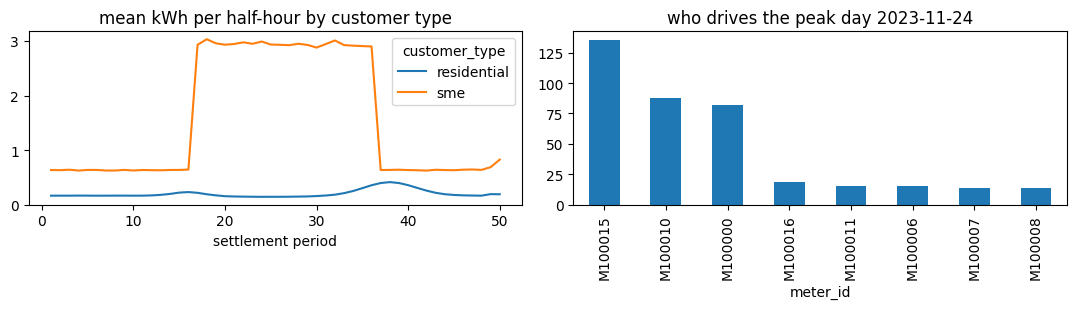

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
by_type.plot(ax=ax[0], title="mean kWh per half-hour by customer type"); ax[0].set_xlabel("settlement period")
peak_day = portfolio.idxmax().tz_convert("Europe/London").strftime("%Y-%m-%d")
contrib = clean[clean["settlement_date"] == peak_day].groupby("meter_id")["kwh"].sum().sort_values(ascending=False)
contrib.head(8).plot.bar(ax=ax[1], title=f"who drives the peak day {peak_day}"); plt.tight_layout()

## 7. Per-meter statistics in one `agg`

Named aggregations keep column names readable. Peak kW = max kWh per half hour × 2.
Load factor = mean / max.

In [18]:
clean["evening_kwh"] = clean["kwh"].where(clean["settlement_period"].between(35, 40), 0.0)   # 17:00-20:00 local
stats = (clean.groupby("meter_id")
              .agg(annual_kwh=("kwh", "sum"),
                   peak_kw=("kwh", lambda s: 2 * s.max()),
                   mean_kw=("kwh", lambda s: 2 * s.mean()),
                   n_rows=("kwh", "size"),
                   n_negative=("kwh", lambda s: (s < 0).sum()),
                   evening_kwh=("evening_kwh", "sum")))
stats["load_factor"] = stats["mean_kw"] / stats["peak_kw"]
stats["evening_share"] = stats["evening_kwh"] / stats["annual_kwh"]
stats["missing_share"] = 1 - stats["n_rows"] / len(grid)
stats = stats.join(attrs)
stats["actual_vs_estimate"] = stats["annual_kwh"] / stats["annual_kwh_estimate"]
stats.drop(columns=["evening_kwh", "n_rows"]).round(3).sort_values("actual_vs_estimate")

,annual_kwh,peak_kw,mean_kw,n_negative,load_factor,evening_share,missing_share,customer_type,has_solar,annual_kwh_estimate,actual_vs_estimate
meter_id,,,,,,,,,,,
M100013,1509.694,1.928,0.172,3597,0.089,0.454,0.001,residential,True,2948.0,0.512
M100007,3878.004,2.424,0.483,0,0.199,0.223,0.083,residential,False,3982.0,0.974
M100011,4544.086,3.328,0.540,0,0.162,0.225,0.039,residential,False,4511.0,1.007
M100002,3804.000,2.734,0.435,0,0.159,0.223,0.001,residential,False,3665.0,1.038
M100016,5502.002,3.306,0.629,0,0.190,0.224,0.001,residential,False,5283.0,1.041
M100005,3151.860,2.038,0.360,0,0.177,0.223,0.001,residential,False,3026.0,1.042
M100015,38292.885,29.358,4.378,0,0.149,0.108,0.001,sme,False,36741.0,1.042
M100000,22561.696,17.970,2.577,0,0.143,0.111,0.001,sme,False,21622.0,1.043
M100001,2385.245,1.720,0.273,0,0.159,0.224,0.001,residential,False,2286.0,1.043


**Interview check:** "M100003 shows 0.95 of estimate and M100011 0.94 — is that
customer behaviour?" No: one has a stuck week, the other a missing fortnight. Look at
`missing_share` before interpreting `actual_vs_estimate`.

## 8. A cross-sectional (panel) model

One Ridge across all meters, features built **per meter** with groupby (lag 48 = same
period yesterday, lag 336 = same period last week, lagged rolling mean), calendar
features, chronological split, and per-meter scaling using train-only statistics.

The leakage rules are the same as for one series, plus one: never let a per-meter
statistic computed on the whole year (mean, std, "typical") into the features.

In [19]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

pnl = clean.sort_values(["meter_id", "utc"]).copy()
g = pnl.groupby("meter_id")["kwh"]
pnl["lag0"] = pnl["kwh"]                                      # the current reading is known at t
pnl["lag48"] = g.shift(48)
pnl["lag336"] = g.shift(336)
pnl["roll48"] = g.transform(lambda s: s.shift(1).rolling(48, min_periods=24).mean())
loc = pnl["utc"].dt.tz_convert("Europe/London")
pnl["hh"] = loc.dt.hour * 2 + loc.dt.minute // 30
pnl["dow"] = loc.dt.dayofweek
pnl["is_sme"] = (pnl["customer_type"] == "sme").astype(int)
pnl["target"] = g.shift(-48)                                  # same period tomorrow

split_time = pd.Timestamp("2023-10-01", tz="UTC")
train = pnl[pnl["utc"] < split_time].dropna(subset=["lag0", "lag48", "lag336", "roll48", "target"])
test = pnl[pnl["utc"] >= split_time].dropna(subset=["lag0", "lag48", "lag336", "roll48", "target"])

# per-meter scaling from TRAIN only
mu = train.groupby("meter_id")["kwh"].mean().rename("mu")
sd = train.groupby("meter_id")["kwh"].std().rename("sd")
def scale(frame):
    f = frame.join(mu, on="meter_id").join(sd, on="meter_id")
    out = pd.DataFrame(index=f.index)
    for c in ["lag0", "lag48", "lag336", "roll48", "target"]:
        out[c] = (f[c] - f["mu"]) / f["sd"]
    out["is_sme"] = f["is_sme"]
    out = pd.concat([out, pd.get_dummies(f["hh"], prefix="hh", dtype=float), pd.get_dummies(f["dow"], prefix="dow", dtype=float)], axis=1)
    return out
Xtr, Xte = scale(train), scale(test)
Xte = Xte.reindex(columns=Xtr.columns, fill_value=0.0)
feats = [c for c in Xtr.columns if c != "target"]

model = Ridge(alpha=1.0).fit(Xtr[feats], Xtr["target"])
pred_z = model.predict(Xte[feats])
test = test.assign(pred=pred_z * test["meter_id"].map(sd) + test["meter_id"].map(mu))
test["naive"] = test["lag0"]       # persistence: tomorrow = today at the same period
print("train/test rows:", len(train), len(test))
print("MAE model %.4f vs persistence %.4f kWh/hh" % (mean_absolute_error(test["target"], test["pred"]), mean_absolute_error(test["target"], test["naive"])))

train/test rows: 252990 87290
MAE model 0.1513 vs persistence 0.1657 kWh/hh


In [20]:
def eval_group(g):
    return pd.Series({"mae_model": mean_absolute_error(g["target"], g["pred"]),
                      "mae_naive": mean_absolute_error(g["target"], g["naive"]),
                      "mean_kwh": g["kwh"].mean()})
per_meter = (test.groupby("meter_id")[["target", "pred", "naive", "kwh"]].apply(eval_group)
                 .assign(skill=lambda t: 1 - t["mae_model"] / t["mae_naive"])
                 .join(attrs[["customer_type", "has_solar"]]))
per_meter.round(3).sort_values("skill")

,mae_model,mae_naive,mean_kwh,skill,customer_type,has_solar
meter_id,,,,,,
M100000,0.532,0.521,1.491,-0.021,sme,False
M100010,0.533,0.525,1.516,-0.015,sme,False
M100015,0.912,0.901,2.523,-0.013,sme,False
M100013,0.058,0.072,0.181,0.202,residential,True
M100016,0.093,0.120,0.362,0.225,residential,False
M100007,0.069,0.089,0.275,0.226,residential,False
M100014,0.064,0.083,0.248,0.227,residential,False
M100019,0.063,0.081,0.243,0.228,residential,False
M100017,0.063,0.082,0.239,0.229,residential,False


**Interview check:** "The model beats persistence by ~23% for every residential meter
and *loses* to it for the three SMEs. Why?" One pooled model with one set of hour and
day-of-week dummies learns the shape of the majority (17 residential meters); the SME
shape (flat 08–18 on weekdays, quiet at weekends) is only represented by an intercept
shift (`is_sme`). Fixes: interact the calendar dummies with customer type, fit per-type
models, or add per-meter period medians computed on train only. The per-meter table is
what reveals this; the pooled MAE alone looked like a clean win.

## Checklist: settlement and panel data

| Check | Idiom |
|---|---|
| periods per day | `groupby(date).period.max().value_counts()` → 46 / 48 / 50 |
| duplicates | `duplicated()` and `duplicated([meter, date, period])` |
| gaps | full `MultiIndex` grid → `reindex` → `isna()` |
| timestamp | local midnight `tz_localize("Europe/London")` → UTC + (period−1)·30 min |
| round-trip | recompute period from UTC and compare |
| sort | `sort_values([meter, time])` before any shift/rolling; assert monotonic per meter |
| lags | `groupby(meter)[col].shift(k)` never bare `shift` |
| rolling | `groupby().rolling()` then `reset_index(level=0, drop=True)`; shift(1) first for features |
| energy vs power | kWh sums; kW = kWh × 2 per half hour; mean for power |
| resample | `groupby([meter, pd.Grouper(key=time, freq="h")]).sum()` |
| portfolio | wide `pivot` for cross-meter sums; coincidence factor |
| scaling | per-meter mean/std from train only |
| reconcile | merge with a second source, `validate="one_to_one"`, ratio table |